In [1]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [4]:
from langchain_ollama import OllamaEmbeddings

embedding_model = OllamaEmbeddings(
    model="bge-m3:latest",
)

In [5]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.load_local(
    "faiss_index",
    embedding_model,
    allow_dangerous_deserialization=True,
)

In [21]:
retriever = vectorstore.as_retriever()

In [6]:
query = "곧 결혼해"

In [7]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str
    retry_count: int

In [8]:
def retrieve(state: AgentState) -> AgentState:
    """
    사용자의 질문에 기반하여 벡터 스토어에서 관련 문서를 검색합니다.

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 검색된 문서가 추가된 state를 반환합니다.
    """
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    docs = retriever.invoke(query)  # 질문과 관련된 문서를 검색합니다.
    return {'context': docs}  # 검색된 문서를 포함한 state를 반환합니다.

In [10]:
from langsmith import Client

client = Client()
prompt = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)

In [11]:
def generate(state: AgentState) -> AgentState:
    """
    주어진 state를 기반으로 RAG 체인을 사용하여 응답을 생성합니다.

    Args:
        state (AgentState): 사용자의 질문과 문맥을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 생성된 응답을 포함하는 state를 반환합니다.
    """
    context = state['context']  # state에서 문맥을 추출합니다.
    query = state['query']      # state에서 사용자의 질문을 추출합니다.

    print("\n--- GENERATE 노드 진입: 최종 답변 생성 중... ---")
    
    # RAG 체인을 구성합니다.
    rag_chain = prompt | llm
    
    # 질문과 문맥을 사용하여 응답을 생성합니다.
    response = rag_chain.invoke({'question': query, 'context': context})
    
    return {'answer': response}  # 생성된 응답을 포함하는 state를 반환합니다.

In [13]:
from langsmith import Client

client = Client()
doc_relevance_prompt = client.pull_prompt("langchain-ai/rag-document-relevance", dangerously_pull_public_prompt=True)

In [14]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    "google_genai:gemini-3.1-flash-lite",
    temperature=0
)

In [15]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal

def check_doc_relevance(state: AgentState) -> Literal['generate', 'rewrite']:
    """
    주어진 state를 기반으로 문서의 관련성을 판단합니다.
    """
    query = state['query']
    context = state['context']
    retry_count = state.get('retry_count', 0)

    prompt_template = ChatPromptTemplate(
        messages=doc_relevance_prompt.messages, 
        template_format="mustache"
    )

    structured_llm = llm.with_structured_output(doc_relevance_prompt.schema_)
    doc_relevance_chain = prompt_template | structured_llm
    
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})
    
    print(f"[관련성 평가] 점수: {response['Score']} / 누적 재시도 횟수: {retry_count}")

    if response['Score'] == 1:
        return 'generate'
    
    if retry_count >= 3:
        print("\n🚨 [경고] 재시도 횟수 초과! 강제로 generate 노드로 이동합니다.")
        return 'generate'
    
    return 'rewrite'

In [17]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# LLM을 활용하여 원본 질문의 의도를 파악하고, 문서 검색에 적합한 키워드 중심으로 질문을 재작성합니다.
rewrite_prompt = PromptTemplate.from_template("""
당신은 사용자의 질문을 기반으로 정보 검색(RAG)을 최적화하는 AI 어시스턴트입니다.
원본 질문을 분석하여 문서 데이터베이스에서 더 정확하게 관련된 문서를 찾을 수 있도록 질문을 재작성해주세요.

다음 지침을 엄격히 따르세요:
1. 질문의 핵심 의도를 파악하고 중요한 키워드를 추출하세요.
2. 모호한 단어나 줄임말은 문맥을 추론하여 명확한 전문 용어나 풀어서 쓴 말로 변경하세요.
3. 불필요한 조사나 어미는 생략하고 핵심 명사구 위주로 재구성해도 좋습니다.
4. 설명이나 서론 없이 '재작성된 질문만' 문자열로 반환하세요.

원본 질문: {query}
재작성된 질문:
""")

def rewrite(state: AgentState) -> AgentState:
    """
    사용자의 질문을 LLM을 사용하여 검색에 최적화된 형태로 재작성합니다.
    """
    query = state['query']
    retry_count = state.get('retry_count', 0)
    print(f"\n--- REWRITE 호출됨: 원본 질문 [{query}] ---")
    
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    response = rewrite_chain.invoke({'query': query})
    
    print(f"--- REWRITE 완료: 재작성된 질문 [{response}] ---")
    
    return {'query': response, 'retry_count': retry_count + 1}

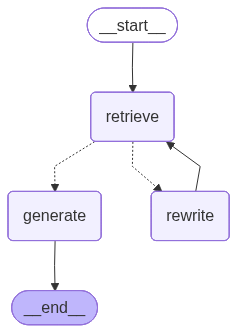

In [18]:
from langgraph.graph import StateGraph
from langgraph.graph import START, END

graph_builder = StateGraph(AgentState)

graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges('retrieve', check_doc_relevance, {"generate": "generate", "rewrite": "rewrite"})
graph_builder.add_edge('rewrite', 'retrieve')
graph_builder.add_edge('generate', END)

graph = graph_builder.compile()
graph

In [19]:
query

'곧 결혼해'

In [22]:
initial_state = {'query': query, 'retry_count': 0}
result = graph.invoke(initial_state)
result

[관련성 평가] 점수: 1 / 누적 재시도 횟수: 0

--- GENERATE 노드 진입: 최종 답변 생성 중... ---


{'query': '곧 결혼해',
 'context': [Document(id='75d21025-febf-48fb-a8f8-ce20ee1421ad', metadata={'producer': 'Microsoft: Print To PDF', 'creator': '', 'creationdate': '2026-01-16T00:25:28+09:00', 'source': '..\\data\\Employee_Benefits_Guide_2026_v1.pdf', 'file_path': '..\\data\\Employee_Benefits_Guide_2026_v1.pdf', 'total_pages': 22, 'format': 'PDF 1.7', 'title': 'Microsoft Word - Employee_Benefits_Guide_2026_v1.docx', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-01-16T00:25:28+09:00', 'trapped': '', 'modDate': "D:20260116002528+09'00'", 'creationDate': "D:20260116002528+09'00'", 'page': 12}, page_content='5.5 다양성 및 포용성 지원 (DEIB & Diversity) \n모든 구성원의 삶의 방식을 존중하며, 전통적 가족 형태를 넘어선 현대적 복지를 \n실현합니다. \nA. 비혼 선언 지원 (Single Life Celebration) \n1. 대상: 만 38 세 이상, 근속 5 년 이상의 임직원 중 비혼을 공식 선언한 자. \n2. 혜택: 결혼 축의금과 동일한 수준의 보상 제공. \no 비혼 축하금 100 만원 지원. \no 리프레시 유급 휴가 5 일 부여. \n3. 제한: 비혼 선언 후 5 년 이내 실제 결혼 시, 기지급된 혜택의 50%를 환수함. \nB. 반려동물 가족 수당 (Pet-Fam Support) \n1. 대상: 반려동물과 함께 거주 중인 임직원

In [23]:
query = "블랙홀의 사건의 지평선이란 무엇인가요?"

In [24]:
initial_state = {'query': query, 'retry_count': 0}
result = graph.invoke(initial_state)
result

[관련성 평가] 점수: 0 / 누적 재시도 횟수: 0

--- REWRITE 호출됨: 원본 질문 [블랙홀의 사건의 지평선이란 무엇인가요?] ---
--- REWRITE 완료: 재작성된 질문 [블랙홀 사건의 지평선(Event Horizon) 정의 및 물리적 특성 설명] ---
[관련성 평가] 점수: 0 / 누적 재시도 횟수: 1

--- REWRITE 호출됨: 원본 질문 [블랙홀 사건의 지평선(Event Horizon) 정의 및 물리적 특성 설명] ---
--- REWRITE 완료: 재작성된 질문 [블랙홀 사건의 지평선(Event Horizon)의 물리적 정의 및 주요 특성 상세 설명] ---
[관련성 평가] 점수: 0 / 누적 재시도 횟수: 2

--- REWRITE 호출됨: 원본 질문 [블랙홀 사건의 지평선(Event Horizon)의 물리적 정의 및 주요 특성 상세 설명] ---
--- REWRITE 완료: 재작성된 질문 [블랙홀 사건의 지평선(Event Horizon) 물리적 정의 및 주요 특성 상세 설명] ---
[관련성 평가] 점수: 0 / 누적 재시도 횟수: 3

🚨 [경고] 재시도 횟수 초과! 강제로 generate 노드로 이동합니다.

--- GENERATE 노드 진입: 최종 답변 생성 중... ---


{'query': '블랙홀 사건의 지평선(Event Horizon) 물리적 정의 및 주요 특성 상세 설명',
 'context': [Document(id='a92b0c96-0a6a-44fd-910b-92327000677b', metadata={'producer': 'Microsoft: Print To PDF', 'creator': '', 'creationdate': '2026-01-16T00:25:28+09:00', 'source': '..\\data\\Employee_Benefits_Guide_2026_v1.pdf', 'file_path': '..\\data\\Employee_Benefits_Guide_2026_v1.pdf', 'total_pages': 22, 'format': 'PDF 1.7', 'title': 'Microsoft Word - Employee_Benefits_Guide_2026_v1.docx', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-01-16T00:25:28+09:00', 'trapped': '', 'modDate': "D:20260116002528+09'00'", 'creationDate': "D:20260116002528+09'00'", 'page': 3}, page_content='6. Teamwork (협력): 혼자 빨리 가기보다 함께 멀리 간다. \n7. Tech (기술): 기술이 우리의 근본임을 잊지 않는다. \n \n2. 인사 및 평가 제도 (HR System) \n2.1 직급 및 호칭 체계 \n테크노빌드는 능력 중심의 수평적 조직 문화를 지향하며 직급 단계를 단순화했습니다. \n직군 구분 \n직급 단계 \n체류 연한 (표준)\n호칭 표기 \n비고 \n사무/연구직 \n(G 직군) \nG1 (Associate) \n3 년 \n프로/연구원 \n대졸 신입 ~ \n사원급 \n \nG2 (Specialist) \n4 년 \n프로/연구원 \n대리 ~ 과장급 \n \n